<a href="https://colab.research.google.com/github/Cukiii69/MyRep/blob/main/SoftComputingFinalExamAleksandarPetkovic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Soft optimization Project
##**Aleksandar Petkovic <div align="right">2024230122</div>**



 For this project  i will:
  * Implement from scratch orginal optimization algoritham
  * Implement my own improvment  
  * Test it on CEC benchamrk   functions
  *  And Compare the orginal version with improved version

In [ ]:
import numpy as np

#CEC Benchmark functions

First i am going to define benchmark functions

I ussed this kaggle code for help :
https://www.kaggle.com/code/kooaslansefat/cec-2022-benchmark

## 1: Bent cigar Function

In [ ]:
def f1_bent_cigar_function(x):
    return x[0]**2 + 10**6 * np.sum(x[1:]**2)

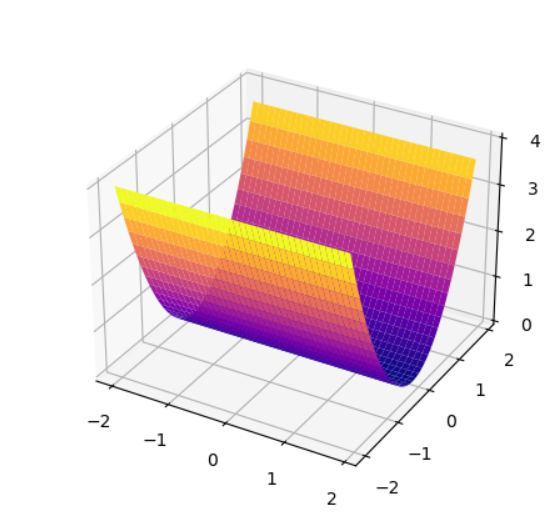



##This is how does the field of search looks alike

## 2: Rastrigin’s Function

In [ ]:
def f2_rastrigin_function(x, A=10):
    return 2*A + np.sum(x**2 - A * np.cos(2 * np.pi * x))

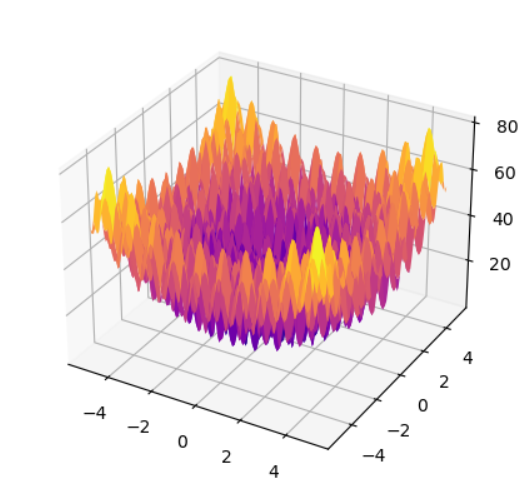


## This one has a lot of local minimum where our algoritham can stuck so it has a lot of traps

## 3: High Conditioned Elliptic Function


In [ ]:
def f3_elliptic(x):
    n = len(x)
    a = 10**6
    res = 0
    for i in range(n):
        res += (a**(i/(n-1))) * x[i]**2
    return res

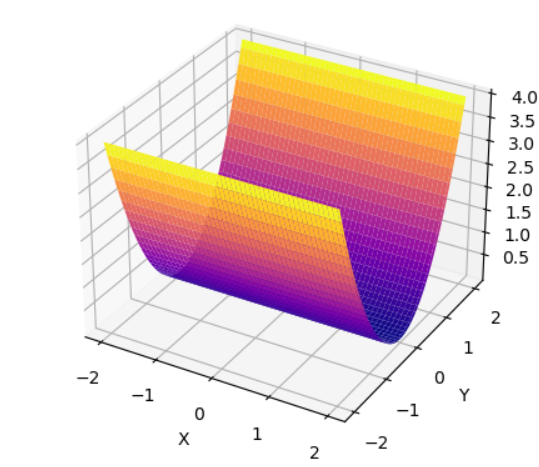

## 4: HGBat Function

In [ ]:
def f4_hgbat(x):
    a1, a2 = -10, -5
    term1 = ((x[0]-a1)**2 + (x[1]-a2)**2)**2
    term2 = ((x[0]-a1) + (x[1]-a2))**2 / 10**6
    return term1 + term2


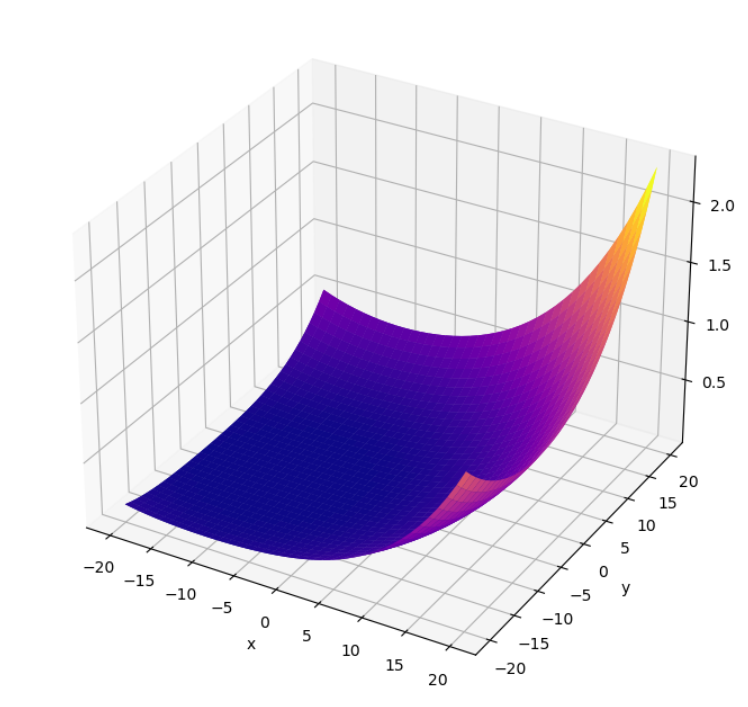

## 5: Rosenbrock’s Function

In [ ]:
def f5_rosenbrock(x):
    return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

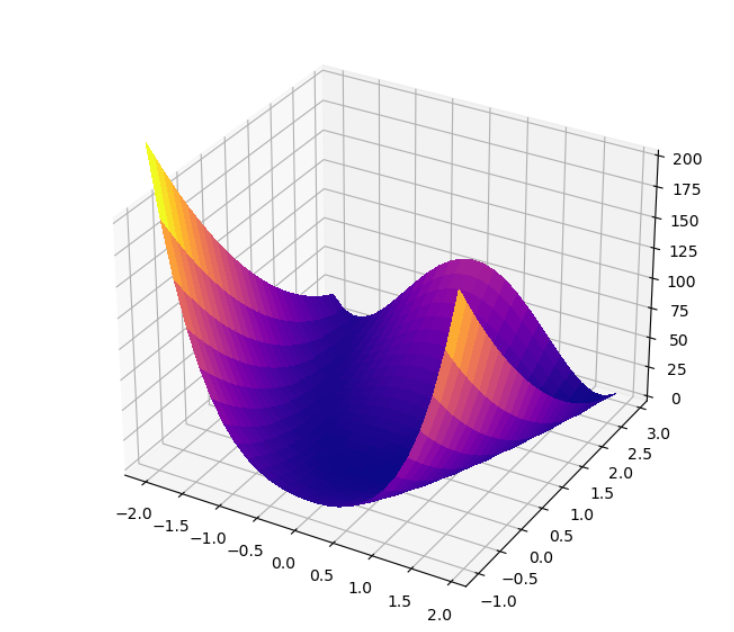

## 6: Griewank’s Function

In [ ]:
def f6_griewank(x):
    D = len(x)
    sum_term = np.sum(x**2) / 4000
    prod_term = np.prod(np.cos(x / np.sqrt(np.arange(1, D + 1))))
    return 1 + sum_term - prod_term

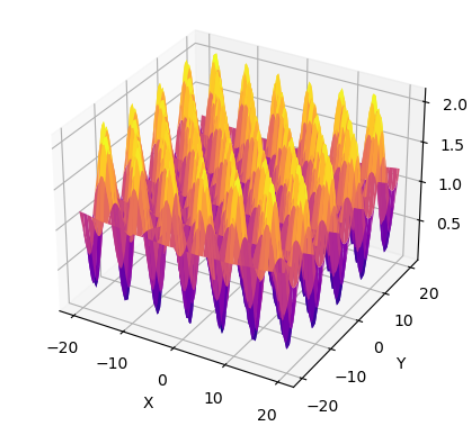

## 7: Ackley’s Function

In [ ]:
def f7_ackley(x):

    term1 = -20 * np.exp(-0.2 * np.sqrt(0.5 * (x[0]**2 + x[1]**2)))
    term2 = -np.exp(0.5 * (np.cos(2*np.pi*x[0]) + np.cos(2*np.pi*x[1])))
    return term1 + term2 + np.e + 20

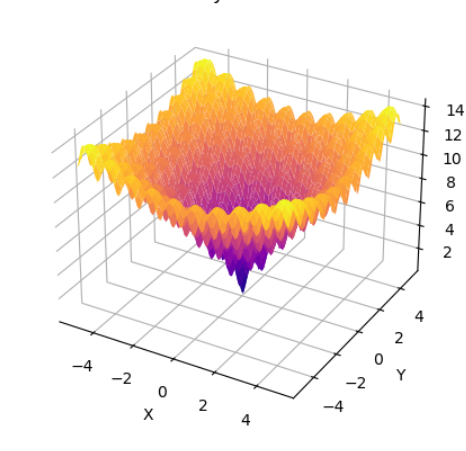

# Implementing Algoritham  PSO


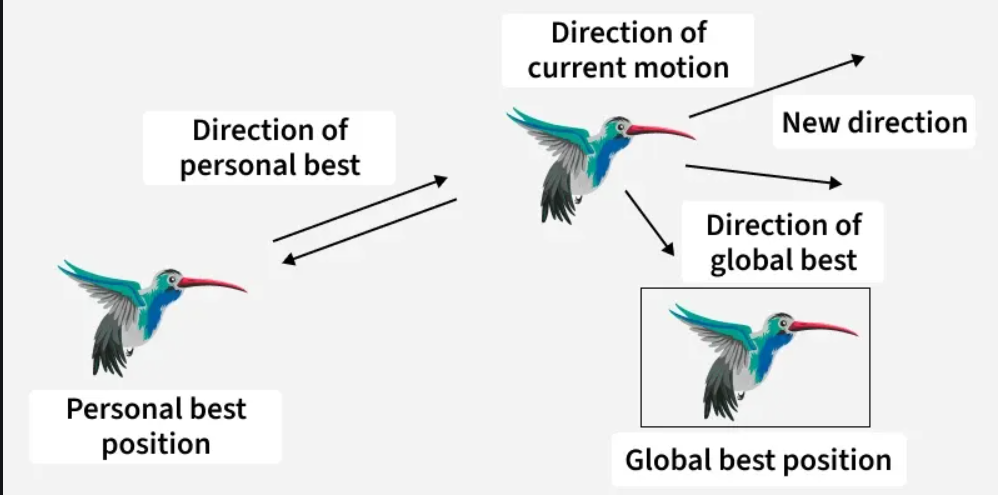

##How PSO works
--------------

Bascily we throw a lot of random particles on a search field
and we add them velocity and randomnes and they start exploring,in each step they move we also have hyperparamtars c1 and c2 that we also add in each step of our exploration

*c1 basicly pulls our particles towards personal best position so far so it can explore around it

*c2 pulls our particles towards best global position so its exploring around it


## Why PSO

I chose pso because its for me one of easier  swarm  algorithams to understand ,not too much code to be too complicated ,its easy to understand ,easy to implement and fast convergence and as we can see its doing pretty good



##

In [ ]:
def initialize_particles(n_particles, bounds, dim):
    positions =np.random.uniform(bounds[0], bounds[1], size=(n_particles, dim))  # Here i am just defining my positions in my bounds
    velocities =np.zeros((n_particles, dim))                                     # also defining velocities for my particles
    return positions, velocities


def evaluate_fitness(positions, obj_func):
    return np.array([obj_func(pos) for pos in positions])         #Here i am just evaluating fitness with predifined fitness functions and i am doing that on whole array

def update_particles(positions, velocities, pbest_positions, gbest_position, bounds, w=0.7, c1=1.5, c2=1.0): #Definig all hypearametars and updating the velocity as in mathematical function
    r1 =np.random.rand(*positions.shape)  #r1 and r2 are just for randomness so we have exploration,and also to have stohastic alg
    r2 = np.random.rand(*positions.shape)  #

    new_velocities = (w* velocities +c1 * r1 * (pbest_positions - positions) +
                      c2 * r2 * (gbest_position - positions))               #Updating velocity

    new_positions = positions + new_velocities                              #updating new position by adding velocity to my position
    new_positions = np.clip(new_positions, bounds[0], bounds[1])            #Making sure our position is in our boundry

    return new_positions, new_velocities


def particle_swarm_optimization(obj_func, n_particles=30, max_iter=100, bounds=[-5, 5], dim=2): #Defining swarm we need func ,n of partices and bounds
    positions,velocities=initialize_particles(n_particles,bounds,dim)        #Initializing swarm for our algoritham


    fitness =evaluate_fitness(positions,obj_func)                                #Evaulating fitness

    pbest_positions = np.copy(positions)
    pbest_fitness = np.copy(fitness)                                                 #Checkhing personal fbest fitness and pos

    best_index = np.argmin(fitness)
    gbest_position = np.copy(positions[best_index])                                 #Getting the best Global position
    gbest_fitness = fitness[best_index]                                             # ANd global best fitness

    best_fitness_over_time = []                                                    #Making a list so we can plot and visualize how our algoritham works over time

    for iteration in range(max_iter):                                             #Iterating throught our max_iter
        positions, velocities = update_particles(                                 #Getting our new updated positons and etc...
            positions,velocities,pbest_positions,gbest_position,bounds
        )


        fitness = evaluate_fitness(positions,obj_func)                          #Evaulating

        for i in range(n_particles):
            if fitness[i] < pbest_fitness[i]:                                    #Here we basicly check in a loop if fitness on a new updated position is better than our current best fitnees
                pbest_fitness[i] = fitness[i]
                pbest_positions[i] = np.copy(positions[i])                       # if so,we updated our best fittnes with a new founded one and also update our position so we can know on which position is our minimum

        current_best_index = np.argmin(pbest_fitness)                            # Here we are doing the same thing but we are doing it on the global solution
        if pbest_fitness[current_best_index] < gbest_fitness:
            gbest_fitness = pbest_fitness[current_best_index]
            gbest_position = np.copy(pbest_positions[current_best_index])

        best_fitness_over_time.append(gbest_fitness)                             #Appendig our best fitnes to list so we can acctualy see how by iterations our algoritham improwes

    return gbest_position, gbest_fitness, best_fitness_over_time #Returning best positon ,best fitness and best_fitness over time

In [ ]:
best_solution,best_fitnes,best_fitnes_over_time = particle_swarm_optimization(
        f2_rastrigin_function,
        n_particles=30,
        max_iter=30,
        bounds=[-10, 10],
        dim=2
    )


print(f"The best fitness algoritham found : {best_fitnes:.4f}")

The best fitness algoritham found : 0.1490


In [ ]:
def initialize_particles(n_particles,bounds,dim):
    positions = np.random.uniform(bounds[0],bounds[1],size=(n_particles,dim))

    velocities = np.zeros((n_particles,dim))
    return positions,velocities


def evaluate_fitness(positions,obj_func):

    return np.array([obj_func(pos) for pos in positions])


def update_particles(positions,velocities,pbest_positions,gbest_position,bounds, w=0.7, c1=1.5, c2=1.0):
    r1 = np.random.rand(*positions.shape)
    r2 = np.random.rand(*positions.shape)

    new_velocities = (w * velocities + c1 * r1 *(pbest_positions- positions) +
                      c2 * r2 * (gbest_position - positions))

    new_positions=positions +new_velocities

    new_positions =np.clip(new_positions,bounds[0],bounds[1])

    return new_positions,new_velocities


def local_search(best_pos,best_fit,obj_func,bounds,step_size=0.1,ls_iter=10): #Here i added local search to improve my algoritham
                                                                             #i added also hyperparametars step size and search iteration
    current_pos = np.copy(best_pos)                                          #------------------------------------------
    current_fit = best_fit                                                   #Copyinh best position and fit
    dim = len(best_pos)

    for _ in range(ls_iter):                                                 #Iterating in range of our search iteration this basicly after our pso is done is doing local search in number of iterations

        noise = np.random.uniform(-step_size,step_size,dim)               #Adding noise(local search) to our position se it can move from currently
        neighbor = current_pos +noise                                      #best position and maybe even find a better one

        neighbor = np.clip(neighbor, bounds[0],bounds[1])                   #Cliping it so we make sure it dosent escape our boundry when we add noise

        neighbor_fit = obj_func(neighbor)                                  #Evaulating fitness on new position

        if neighbor_fit < current_fit:
            current_pos = neighbor                                          #Checkhing if the fitnes of the new position is lower(better)
            current_fit = neighbor_fit                                      #Than the old one

    return current_pos, current_fit                                         #And we are returning positons and fits


def particle_swarm_optimization_with_local_search(obj_func,n_particles=30,max_iter=100,bounds=[-5,5],dim=2,ls_step_size=0.1,ls_iter=5):
    positions, velocities = initialize_particles(n_particles,bounds,dim)
    fitness = evaluate_fitness(positions, obj_func)

    pbest_positions = np.copy(positions)
    pbest_fitness = np.copy(fitness)


    best_index = np.argmin(fitness)
    gbest_position = np.copy(positions[best_index])
    gbest_fitness = fitness[best_index]

    best_fitness_over_time = []

    for iteration in range(max_iter):

        positions, velocities = update_particles(
            positions, velocities, pbest_positions, gbest_position, bounds
        )
        fitness = evaluate_fitness(positions, obj_func)

        for i in range(n_particles):

            if fitness[i] < pbest_fitness[i]:
                pbest_fitness[i] = fitness[i]

                pbest_positions[i] = np.copy(positions[i])


        current_best_index = np.argmin(pbest_fitness)
        if pbest_fitness[current_best_index] < gbest_fitness:
            gbest_fitness = pbest_fitness[current_best_index]
            gbest_position = np.copy(pbest_positions[current_best_index])


        gbest_position, gbest_fitness = local_search(
            gbest_position,gbest_fitness,obj_func,bounds
        )

        best_fitness_over_time.append(gbest_fitness)


    return gbest_position, gbest_fitness, best_fitness_over_time

In [ ]:
best_solution,best_fitnes_local_search,best_fitness_over_time_local_search= particle_swarm_optimization_with_local_search(
        f2_rastrigin_function,
        n_particles=30,
        max_iter=30,
        bounds=[-10,10],
        dim=2
    )

print(f"The best fitness  algoritham found : {best_fitnes_local_search:.4f}")

The best fitness  algoritham found : 0.0322


Text(0, 0.5, 'Fitnes')

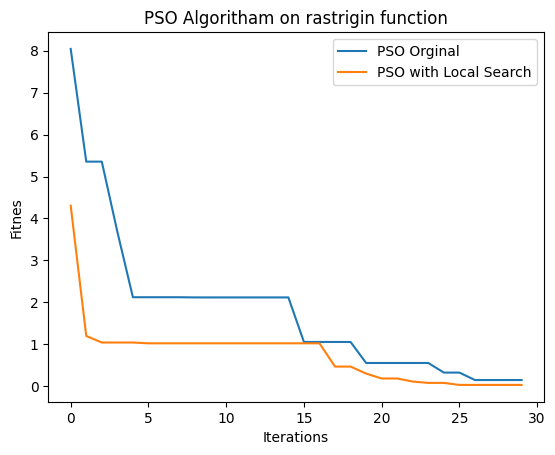

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(best_fitnes_over_time,label= "PSO Orginal")
plt.plot(best_fitness_over_time_local_search,label="PSO with Local Search")
plt.title("PSO Algoritham on rastrigin function")
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Fitnes')

##Plot
**We can clearly see that local search is working a lot faster than the orginal which means implementation is succsecfuly**


In [ ]:
best_solution_f1,best_fitnes_f1,fitness_over_time_f1 = particle_swarm_optimization(
        f1_bent_cigar_function,
        n_particles=30,
        max_iter=30,
        bounds=[-10, 10],
        dim=2
    )


print(f"The best fitness our orginal algoritham found : {best_fitnes:.4f}")

The best fitness our algoritham found : 0.1490


In [ ]:
best_solution_f1,best_fitnes_local_search_f1,best_fitness_over_time_local_search_f1= particle_swarm_optimization_with_local_search(
        f1_bent_cigar_function,
        n_particles=30,
        max_iter=30,
        bounds=[-10,10],
        dim=2
    )

print(f"The best fitness  algoritham found with local search : {best_fitnes_local_search:.4f}")

The best fitness  algoritham found : 0.0322


Text(0, 0.5, 'Fitnes')

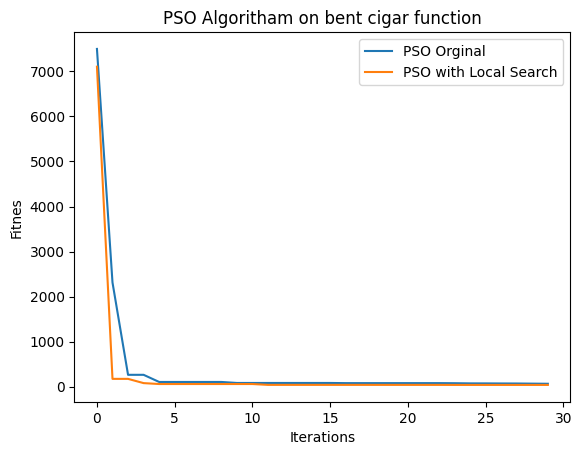

In [ ]:
plt.figure()
plt.plot(fitness_over_time_f1,label= "PSO Orginal")
plt.plot(best_fitness_over_time_local_search_f1,label="PSO with Local Search")
plt.title("PSO Algoritham on bent cigar function")
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Fitnes')

In [ ]:
for i in range(30):


    np.random.seed(47)
    best_solution_f7,best_fitnes_f7,fitness_over_time_f7 = particle_swarm_optimization(
        f7_ackley,
        n_particles=50,
        max_iter=30,
        bounds=[-10, 10],
        dim=2
    )

    np.random.seed(47)
    best_solution_f7_local_search,best_fitnes_local_search_f7,best_fitness_over_time_local_search_f7= particle_swarm_optimization_with_local_search(
        f7_ackley,
        n_particles=50,
        max_iter=30,
        bounds=[-10,10],
        dim=2
    )

print(f"The best fitness our algoritham found on ashley : {best_fitnes_f7:.4f}")
print(f"The best fitness  algoritham found on ashley with LS  : {best_fitnes_local_search_f7:.4f}")

The best fitness our algoritham found on ashley : 0.0019
The best fitness  algoritham found on ashley with LS  : 0.0028


Text(0, 0.5, 'Fitnes')

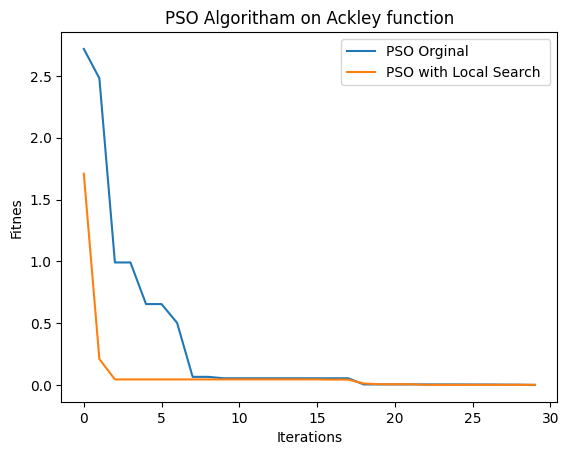

In [ ]:
plt.figure()
plt.plot(fitness_over_time_f7,label= "PSO Orginal")
plt.plot(best_fitness_over_time_local_search_f7,label="PSO with Local Search ")
plt.title("PSO Algoritham on Ackley function")
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Fitnes')